# Tesla Deliveries:- End-to-End ML Pipeline
### Data Science Celebal Excellence Internship Assignment

Dataset covers Tesla deliveries from 2015 to 2025 across regions and models.

Goal: Predict average price and delivery volumes using regression, with time series forecasting.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

In [74]:
df = pd.read_csv('Tesla_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [76]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [77]:
print('Missing values :-')
print(df.isnull().sum())

Missing values :-
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [78]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [79]:
df = df.drop_duplicates()

num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print('After cleaning missing values:')
print(df.isnull().sum())

After cleaning missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


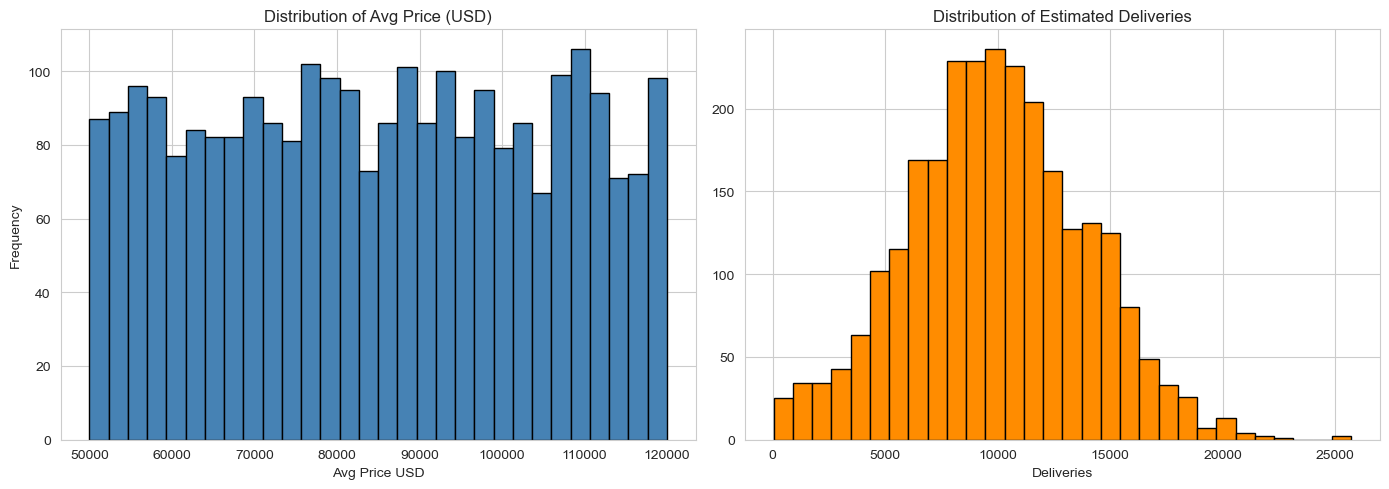

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Avg_Price_USD'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Avg Price (USD)')
axes[0].set_xlabel('Avg Price USD')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Estimated_Deliveries'], bins=30, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Estimated Deliveries')
axes[1].set_xlabel('Deliveries')

plt.tight_layout()
plt.show()

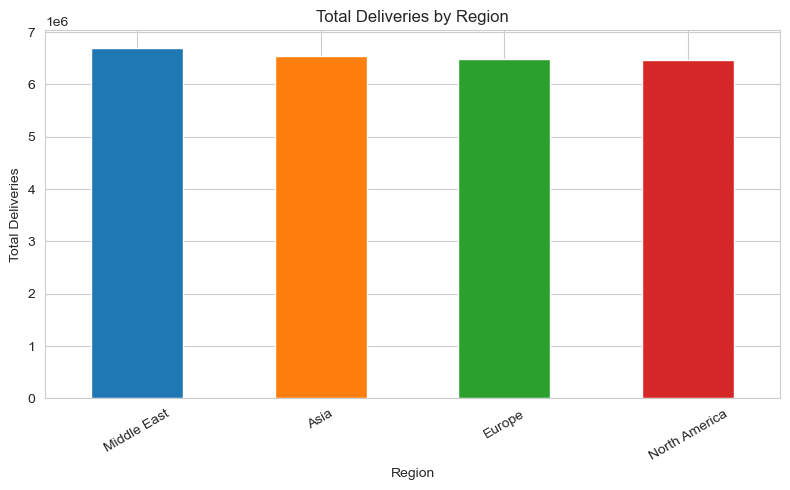

In [81]:
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_deliveries.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

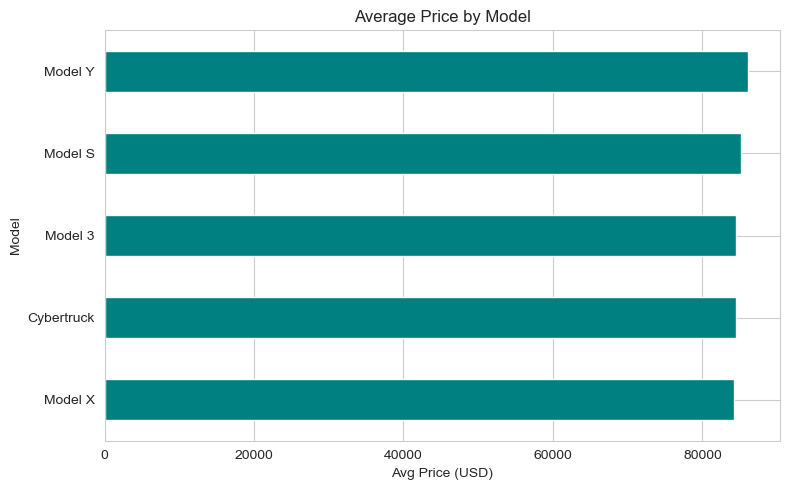

In [82]:
model_price = df.groupby('Model')['Avg_Price_USD'].mean().sort_values()

plt.figure(figsize=(8, 5))
model_price.plot(kind='barh', color='teal')
plt.title('Average Price by Model')
plt.xlabel('Avg Price (USD)')
plt.tight_layout()
plt.show()

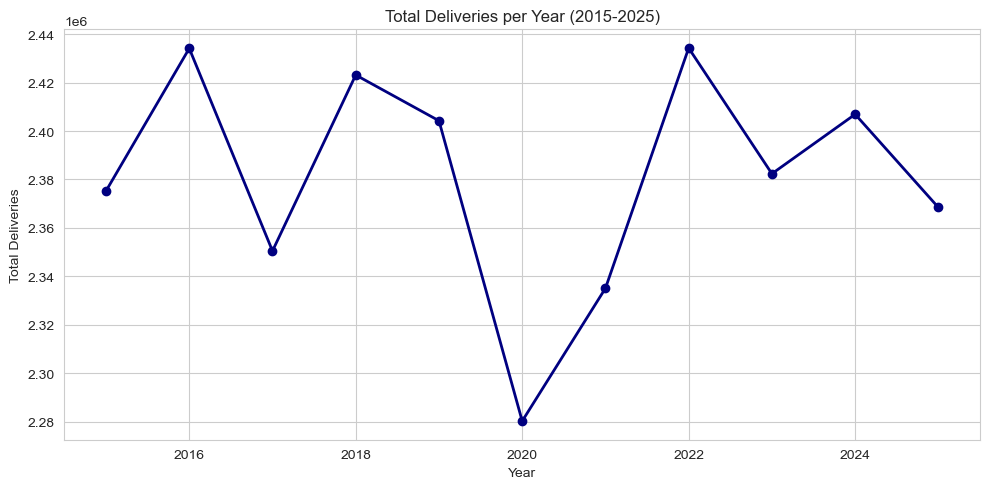

In [83]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='navy', linewidth=2)
plt.title('Total Deliveries per Year (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()

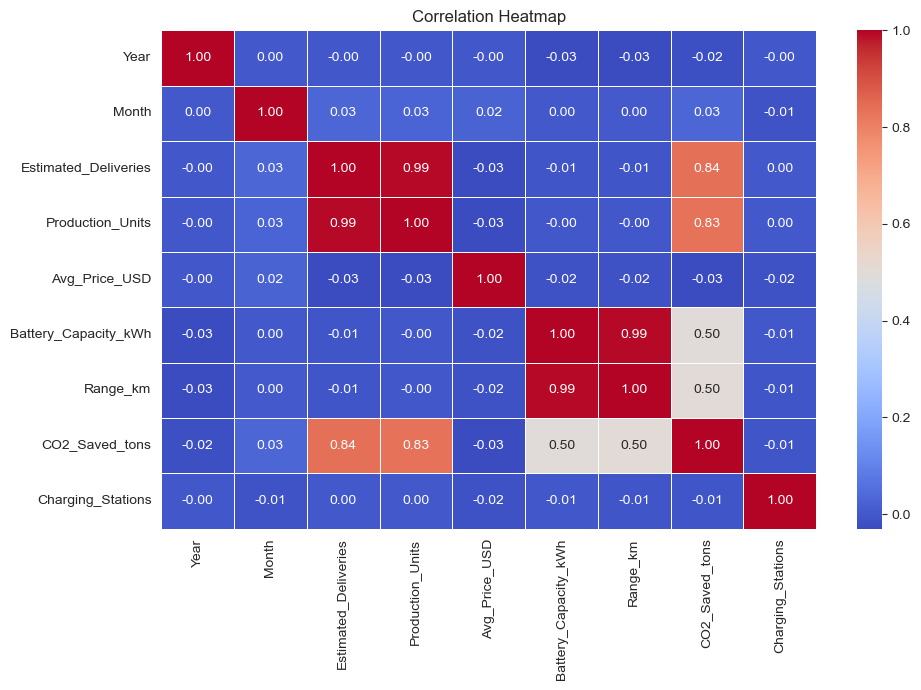

In [84]:
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

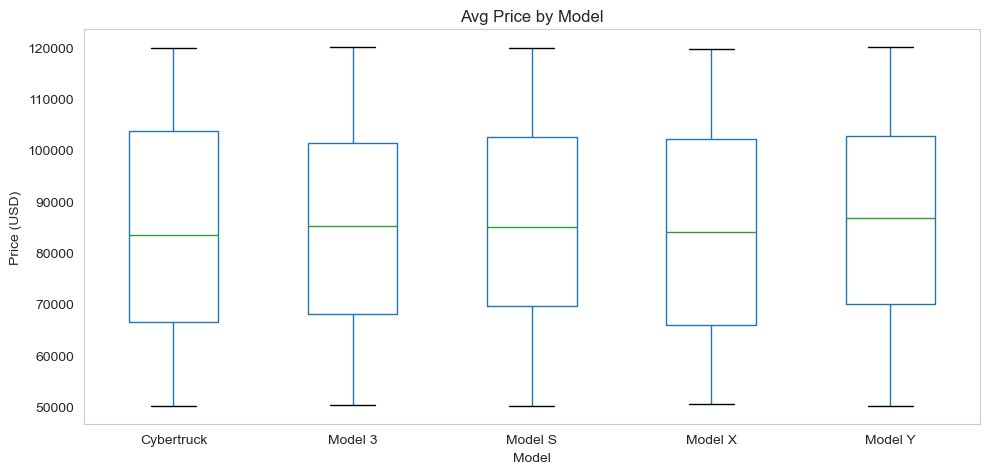

In [85]:
plt.figure(figsize=(10, 5))
df.boxplot(column='Avg_Price_USD', by='Model', grid=False)
plt.title('Avg Price by Model')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

In [86]:
df_model = df.copy()

le_region = LabelEncoder()
le_model  = LabelEncoder()

df_model['Region_enc']     = le_region.fit_transform(df_model['Region'])
df_model['Model_enc']      = le_model.fit_transform(df_model['Model'])

df_model = pd.get_dummies(df_model, columns=['Source_Type'], drop_first=True)

df_model.drop(columns=['Region', 'Model'], inplace=True)

print('After encoding shape:', df_model.shape)
df_model.head(3)

After encoding shape: (2640, 13)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_enc,Model_enc,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,1,2,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,0,3,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,3,3,True,False


In [87]:
df_model['Price_per_km'] = df_model['Avg_Price_USD'] / df_model['Range_km']

df_model['Delivery_per_station'] = df_model['Estimated_Deliveries'] / df_model['Charging_Stations']

df_model['CO2_per_delivery'] = df_model['CO2_Saved_tons'] / (df_model['Estimated_Deliveries'] + 1)  # +1 to avoid div by 0

df_model['Quarter'] = ((df_model['Month'] - 1) // 3) + 1

print('New features added, Shape now:', df_model.shape)

New features added, Shape now: (2640, 17)


In [88]:
TARGET = 'Avg_Price_USD'

drop_cols = [TARGET]
X = df_model.drop(columns=drop_cols)
y = df_model[TARGET]

X = X.astype(float)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (2640, 16)
Target shape: (2640,)


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', X_train_scaled.shape)
print('Test  size:', X_test_scaled.shape)

Train size: (2112, 16)
Test  size: (528, 16)


In [90]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    
    print(f'{name} :- ')
    print(f'MAE  : {mae:.2f}')
    print(f'RMSE : {rmse:.2f}')
    print(f'R2   : {r2:.4f}')
    print()
    return preds, r2

In [91]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, max_iter=5000))
])

preds_lr,    r2_lr    = evaluate_model('Linear Regression', lr_pipe,    X_train, X_test, y_train, y_test)
preds_ridge, r2_ridge = evaluate_model('Ridge (L2)',         ridge_pipe, X_train, X_test, y_train, y_test)
preds_lasso, r2_lasso = evaluate_model('Lasso (L1)',         lasso_pipe, X_train, X_test, y_train, y_test)

Linear Regression :- 
MAE  : 4997.71
RMSE : 6138.22
R2   : 0.9001

Ridge (L2) :- 
MAE  : 4992.76
RMSE : 6136.39
R2   : 0.9001

Lasso (L1) :- 
MAE  : 4991.67
RMSE : 6135.15
R2   : 0.9002



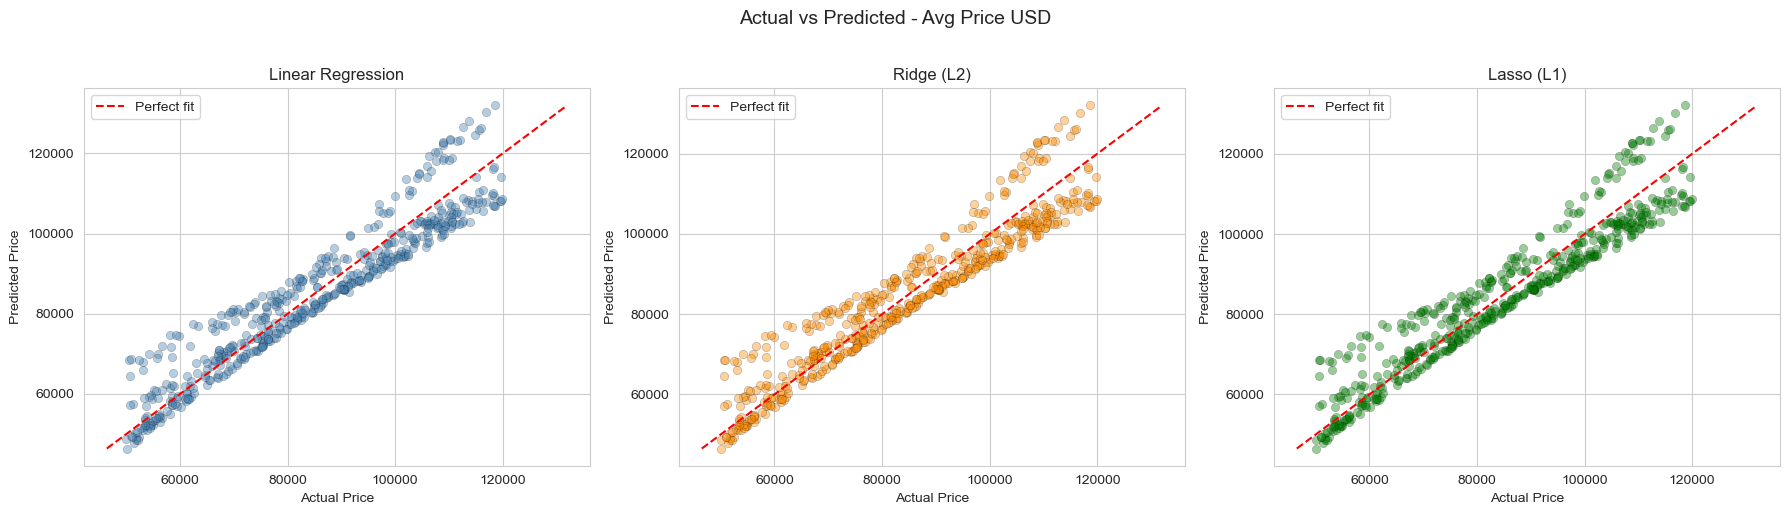

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']
preds_list  = [preds_lr, preds_ridge, preds_lasso]
colors      = ['steelblue', 'darkorange', 'green']

for ax, name, preds, color in zip(axes, model_names, preds_list, colors):
    ax.scatter(y_test, preds, alpha=0.4, color=color, edgecolor='k', linewidths=0.3)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(name)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

plt.suptitle('Actual vs Predicted - Avg Price USD', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [93]:
cv_results = {}

for name, pipe in [('LinearRegression', lr_pipe), ('Ridge', ridge_pipe), ('Lasso', lasso_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name}: mean R2 = {scores.mean():.4f}, std = {scores.std():.4f}')

LinearRegression: mean R2 = 0.8993, std = 0.0059
Ridge: mean R2 = 0.8992, std = 0.0060
Lasso: mean R2 = 0.8992, std = 0.0059


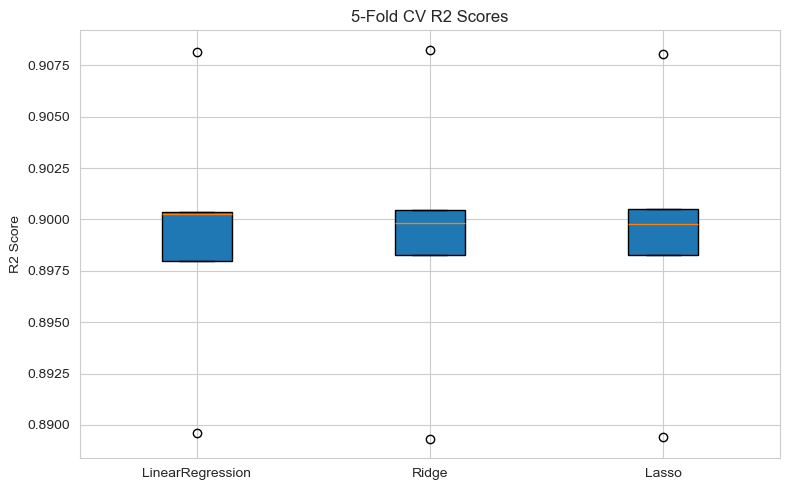

In [94]:
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
plt.title('5-Fold CV R2 Scores')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

In [95]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]
}

grid_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV R2 :', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 7 candidates, totalling 35 fits


Best params: {'model__alpha': 0.01}
Best CV R2 : 0.8992


In [96]:
best_ridge = grid_search.best_estimator_
best_preds = best_ridge.predict(X_test)

print('Test MAE :', round(mean_absolute_error(y_test, best_preds), 2))
print('Test RMSE:', round(np.sqrt(mean_squared_error(y_test, best_preds)), 2))
print('Test R2  :', round(r2_score(y_test, best_preds), 4))

Test MAE : 4994.45
Test RMSE: 6136.66
Test R2  : 0.9001


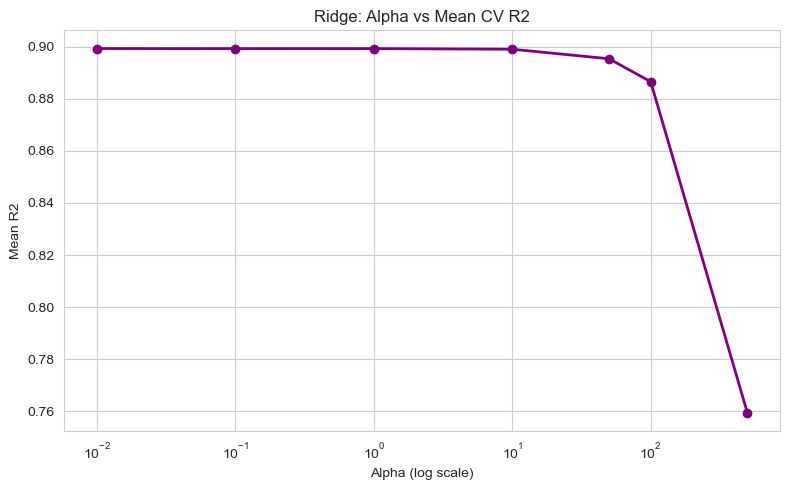

In [97]:
alphas  = param_grid['model__alpha']
cv_means = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_means, marker='o', color='purple', linewidth=2)
plt.xscale('log')
plt.title('Ridge: Alpha vs Mean CV R2')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean R2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [98]:
summary = []

for name, pipe, preds in [
    ('Linear Regression', lr_pipe,    preds_lr),
    ('Ridge (L2)',        ridge_pipe,  preds_ridge),
    ('Lasso (L1)',        lasso_pipe,  preds_lasso),
    ('Ridge Tuned',      best_ridge,  best_preds)
]:
    summary.append({
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_test, preds), 2),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R2'   : round(r2_score(y_test, preds), 4)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Model,MAE,RMSE,R2
0,Linear Regression,4997.71,6138.22,0.9001
1,Ridge (L2),4992.76,6136.39,0.9001
2,Lasso (L1),4991.67,6135.15,0.9002
3,Ridge Tuned,4994.45,6136.66,0.9001


Aggregate monthly deliveries globally and build a forecasting model using lag features and rolling statistics.

In [99]:
ts_df = df.copy()
ts_df['Date'] = pd.to_datetime(ts_df[['Year', 'Month']].assign(Day=1))

monthly = ts_df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
monthly = monthly.sort_values('Date').reset_index(drop=True)
monthly.rename(columns={'Estimated_Deliveries': 'Deliveries'}, inplace=True)

print('Time series length:', len(monthly))
monthly.head(10)

Time series length: 132


,Date,Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264
5,2015-06-01,198787
6,2015-07-01,177759
7,2015-08-01,214223
8,2015-09-01,188448
9,2015-10-01,221541


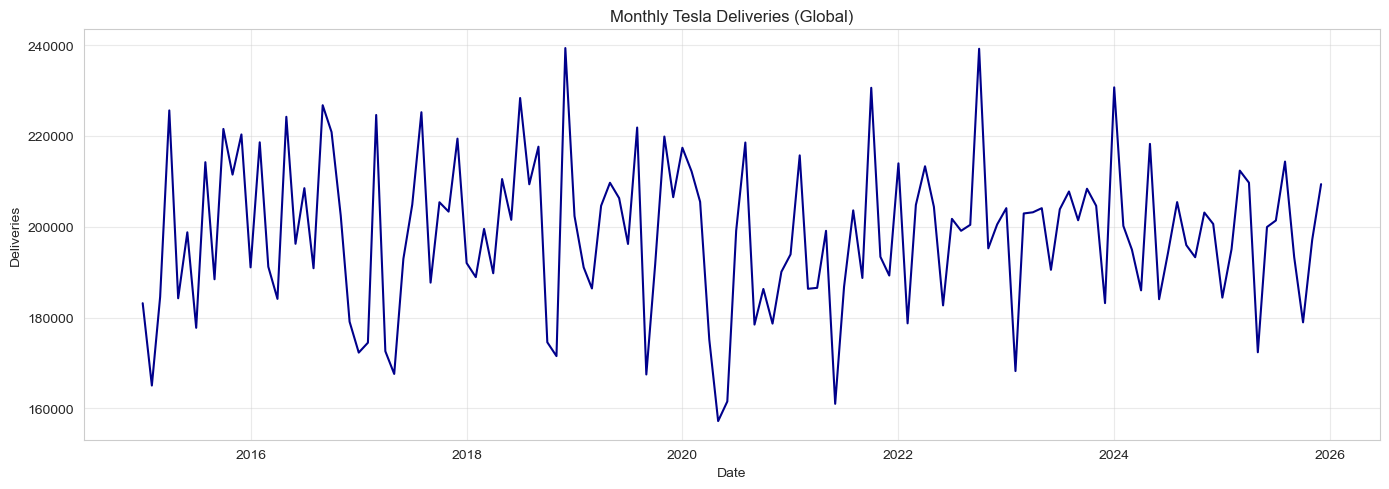

In [100]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Deliveries'], color='darkblue', linewidth=1.5)
plt.title('Monthly Tesla Deliveries (Global)')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

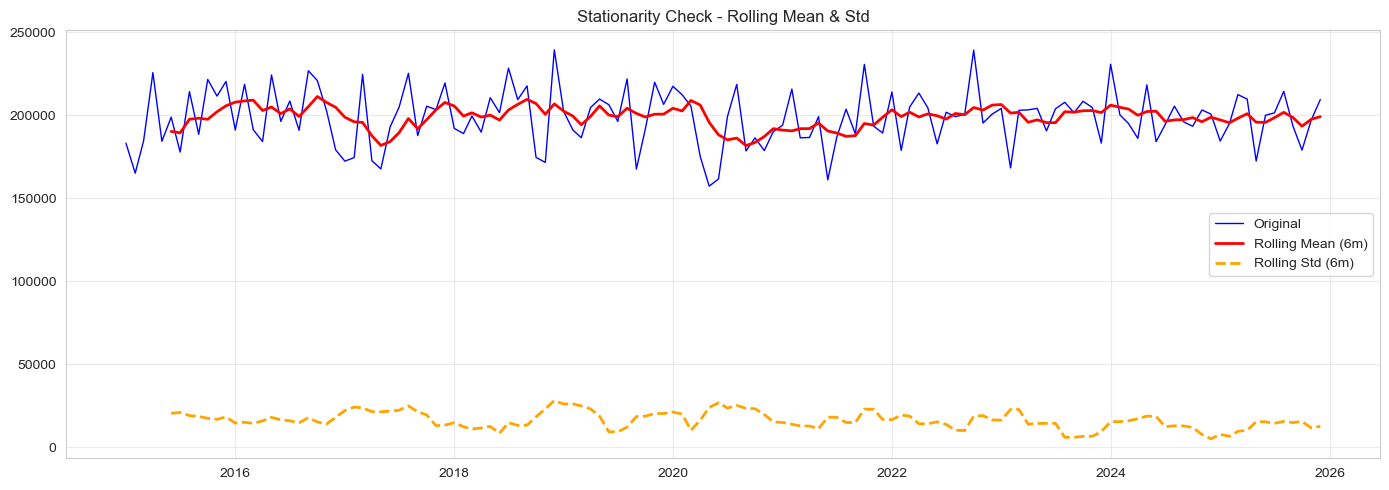

In [101]:
rolling_mean = monthly['Deliveries'].rolling(window=6).mean()
rolling_std  = monthly['Deliveries'].rolling(window=6).std()

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Deliveries'],  label='Original',       color='blue',   linewidth=1)
plt.plot(monthly['Date'], rolling_mean,            label='Rolling Mean (6m)', color='red',    linewidth=2)
plt.plot(monthly['Date'], rolling_std,             label='Rolling Std (6m)',  color='orange', linewidth=2, linestyle='--')
plt.title('Stationarity Check - Rolling Mean & Std')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [102]:
fc = monthly.copy()

for lag in [1, 2, 3, 6, 12]:
    fc[f'lag_{lag}'] = fc['Deliveries'].shift(lag)

fc['roll_mean_3']  = fc['Deliveries'].shift(1).rolling(3).mean()
fc['roll_mean_6']  = fc['Deliveries'].shift(1).rolling(6).mean()
fc['roll_std_3']   = fc['Deliveries'].shift(1).rolling(3).std()

fc['Month']   = fc['Date'].dt.month
fc['Year']    = fc['Date'].dt.year
fc['Quarter'] = fc['Date'].dt.quarter

fc['diff_1'] = fc['Deliveries'].diff(1)

fc.dropna(inplace=True)
print('Forecasting dataset shape:', fc.shape)
fc.head()

Forecasting dataset shape: (120, 14)


,Date,Deliveries,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,Month,Year,Quarter,diff_1
12,2016-01-01,191069,220332.0,211490.0,221541.0,177759.0,183180.0,217787.666667,205632.166667,5487.337636,1,2016,1,-29263.0
13,2016-02-01,218600,191069.0,220332.0,211490.0,214223.0,165053.0,207630.333333,207850.500000,15008.449698,2,2016,1,27531.0
14,2016-03-01,191208,218600.0,191069.0,220332.0,188448.0,184567.0,210000.333333,208580.000000,16417.871127,3,2016,1,-27392.0
15,2016-04-01,184134,191208.0,218600.0,191069.0,221541.0,225623.0,200292.333333,209040.000000,15855.056743,4,2016,2,-7074.0
16,2016-05-01,224220,184134.0,191208.0,218600.0,211490.0,184264.0,197980.666667,202805.500000,18203.792169,5,2016,2,40086.0


In [103]:
feature_cols = [c for c in fc.columns if c not in ['Date', 'Deliveries']]

X_ts = fc[feature_cols].astype(float)
y_ts = fc['Deliveries']

split_idx = len(X_ts) - 12

X_tr_ts = X_ts.iloc[:split_idx]
X_te_ts = X_ts.iloc[split_idx:]
y_tr_ts = y_ts.iloc[:split_idx]
y_te_ts = y_ts.iloc[split_idx:]

test_dates = fc['Date'].iloc[split_idx:]

print('Train size:', len(X_tr_ts))
print('Test size :', len(X_te_ts))

Train size: 108
Test size : 12


In [104]:
ts_scaler = StandardScaler()
X_tr_ts_sc = ts_scaler.fit_transform(X_tr_ts)
X_te_ts_sc = ts_scaler.transform(X_te_ts)

ts_model = Ridge(alpha=10.0)
ts_model.fit(X_tr_ts_sc, y_tr_ts)
ts_preds = ts_model.predict(X_te_ts_sc)

ts_mae  = mean_absolute_error(y_te_ts, ts_preds)
ts_rmse = np.sqrt(mean_squared_error(y_te_ts, ts_preds))
ts_r2   = r2_score(y_te_ts, ts_preds)

print(f'Forecasting MAE  : {ts_mae:.2f}')
print(f'Forecasting RMSE : {ts_rmse:.2f}')
print(f'Forecasting R2   : {ts_r2:.4f}')

Forecasting MAE  : 2303.55
Forecasting RMSE : 2799.24
Forecasting R2   : 0.9527


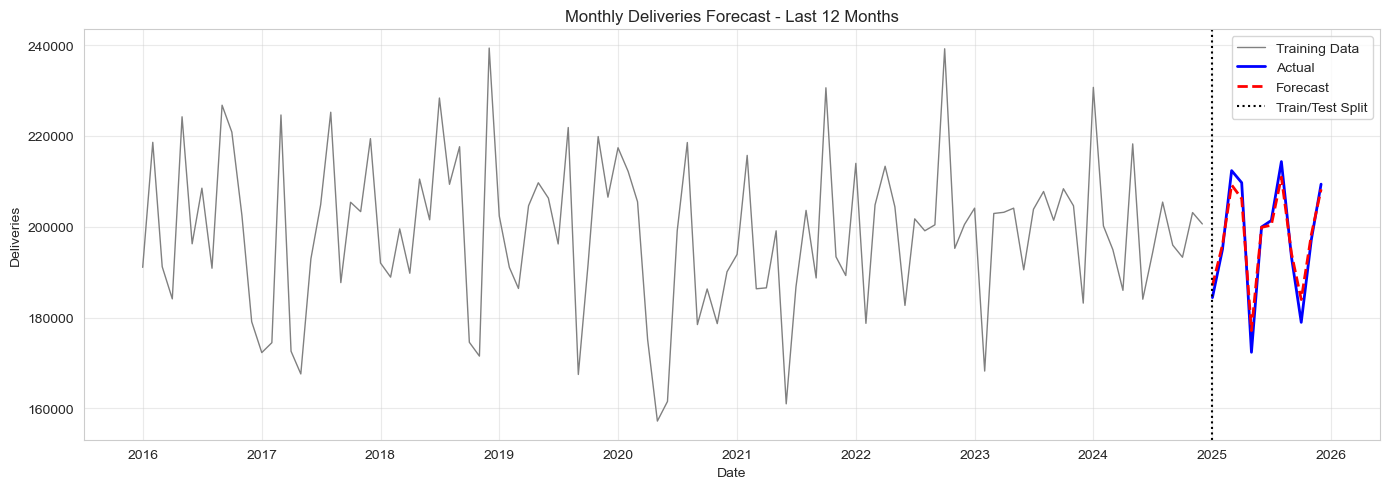

In [105]:
# forecast vs actual plot
plt.figure(figsize=(14, 5))
plt.plot(fc['Date'].iloc[:split_idx], y_tr_ts, color='gray', label='Training Data', linewidth=1)
plt.plot(test_dates, y_te_ts.values,   color='blue',  label='Actual',    linewidth=2)
plt.plot(test_dates, ts_preds,          color='red',   label='Forecast',  linewidth=2, linestyle='--')
plt.axvline(x=test_dates.iloc[0], color='black', linestyle=':', linewidth=1.5, label='Train/Test Split')
plt.title('Monthly Deliveries Forecast - Last 12 Months')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [106]:
train_preds = best_ridge.predict(X_train)
test_preds_final = best_ridge.predict(X_test)

train_r2 = r2_score(y_train, train_preds)
test_r2  = r2_score(y_test, test_preds_final)

print(f'Train R2 : {train_r2:.4f}')
print(f'Test  R2 : {test_r2:.4f}')
print(f'Gap      : {train_r2 - test_r2:.4f}')

if train_r2 - test_r2 > 0.1:
    print('Slight overfitting. Ridge regularization is helping but could increase alpha.')
elif test_r2 < 0.5:
    print('Model might be underfitting. Consider more features or polynomial terms.')
else:
    print('Good bias-variance balance.')

Train R2 : 0.9013
Test  R2 : 0.9001
Gap      : 0.0012
Good bias-variance balance.


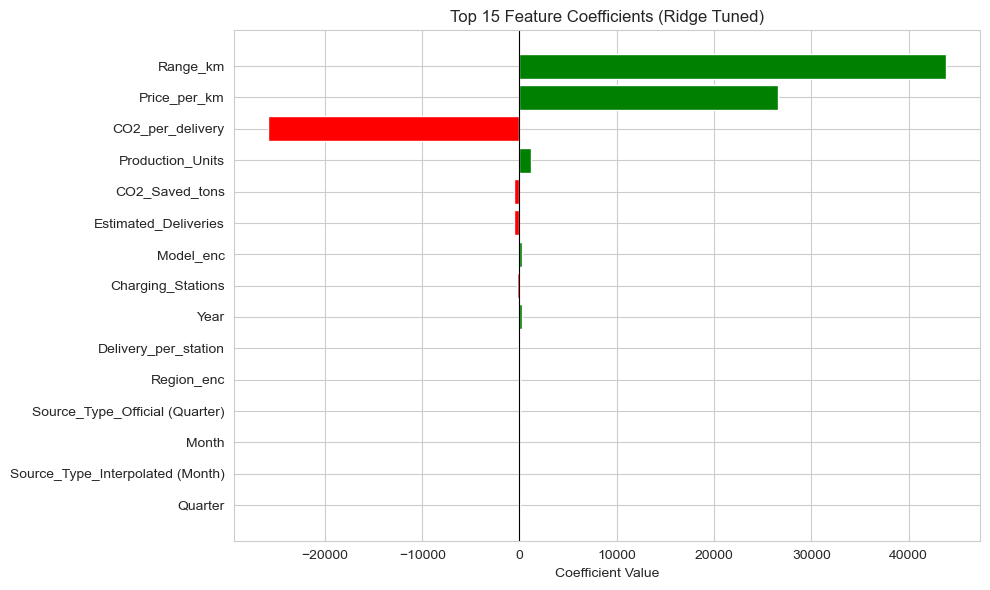

In [107]:
ridge_coefs = best_ridge.named_steps['model'].coef_
feat_names  = X.columns.tolist()

coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': ridge_coefs})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors_bar = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients (Ridge Tuned)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

**Pipeline Summary:**

1. **Data Cleaning** - checked for nulls, duplicates, and imputed safely
2. **EDA** - visualized distributions, trends, regional patterns, correlations
3. **Encoding** - used Label Encoding for ordinal-like features and One-Hot for nominal
4. **Feature Engineering** - created meaningful derived features (price per km, CO2 per delivery etc.)
5. **Feature Scaling** - StandardScaler to normalize all numeric features
6. **Pipelines** - wrapped preprocessing + model into sklearn Pipelines for clean workflow
7. **Models Compared** - Linear Regression, Ridge (L2), Lasso (L1)
8. **Cross Validation** - 5-fold CV to get reliable generalization estimate
9. **Hyperparameter Tuning** - GridSearchCV to find optimal Ridge alpha
10. **Time Series** - monthly aggregation, lag features, rolling stats, stationarity check, chronological split, Ridge-based forecasting
11. **Bias-Variance** - compared train vs test R2 to diagnose under/overfitting

**Best Model:** Ridge with tuned alpha gives the best balance of low error and good generalization.

**Key Insight:** Battery capacity, range, and charging infrastructure are strong predictors of pricing. Time series shows clear growth trend with some seasonal dips.